<a href="https://colab.research.google.com/github/Krishrdx/ML_to_GenAI_Journey/blob/main/Month_01_Foundations/Week_04_Machine_modelling/Day_06_HandlingMissingData.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("/content/data_science_job.csv")

In [3]:
df.sample(3)

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
2419,18147,city_23,0.899,Male,Has relevent experience,no_enrollment,High School,NaN,7.0,100-500,Pvt Ltd,30.0,0.0
9428,29834,city_21,0.624,Male,Has relevent experience,Part time course,Graduate,STEM,7.0,10000+,Pvt Ltd,204.0,1.0
1318,24377,city_114,0.926,NaN,Has relevent experience,no_enrollment,Masters,Other,7.0,1000-4999,Pvt Ltd,57.0,0.0


In [8]:
df.shape

(19158, 13)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  18679 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  float64
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  training_hours          18392 non-null  float64
 12  target                  19158 non-null  float64
dtypes: float64(4), int64(1), object(8)
memory usage: 1.9+ MB


In [6]:
df.isnull().sum()

,0
enrollee_id,0
city,0
city_development_index,479
gender,4508
relevent_experience,0
enrolled_university,386
education_level,460
major_discipline,2813
experience,65
company_size,5938


In [9]:
df.isnull().mean()*100

,0
enrollee_id,0.000000
city,0.000000
city_development_index,2.500261
gender,23.530640
relevent_experience,0.000000
enrolled_university,2.014824
education_level,2.401086
major_discipline,14.683161
experience,0.339284
company_size,30.994885


In [14]:
cols = [var for var in df.columns if df[var].isnull().mean() < 0.05
          and df[var].isnull().mean() > 0]
cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [15]:
df[cols].sample(3)

,city_development_index,enrolled_university,education_level,experience,training_hours
4679,0.555,no_enrollment,Masters,12.0,25.0
11788,0.910,no_enrollment,Graduate,9.0,11.0
2557,0.920,no_enrollment,Graduate,20.0,53.0


In [21]:
len(df[cols].dropna())/len(df)

0.8968577095730244

In [22]:
new_df = df[cols].dropna()

In [23]:
new_df.shape

(17182, 5)

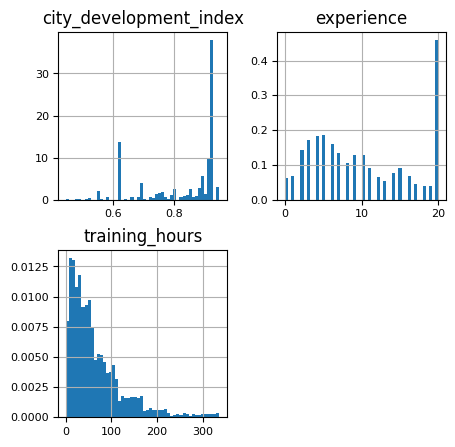

In [28]:
new_df.hist(figsize=(5,5), bins=50, xlabelsize=8, ylabelsize=8, density = True)
plt.show()

<Axes: >

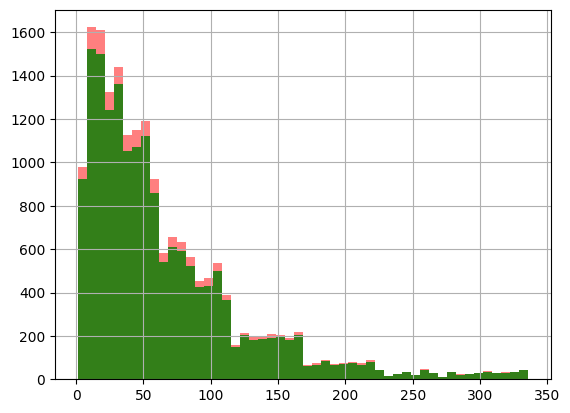

In [31]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['training_hours'].hist(bins=50, ax=ax, color='red', alpha=0.5)

# new data
new_df['training_hours'].hist(bins=50, ax=ax, color='green', alpha=0.8)

<Axes: ylabel='Density'>

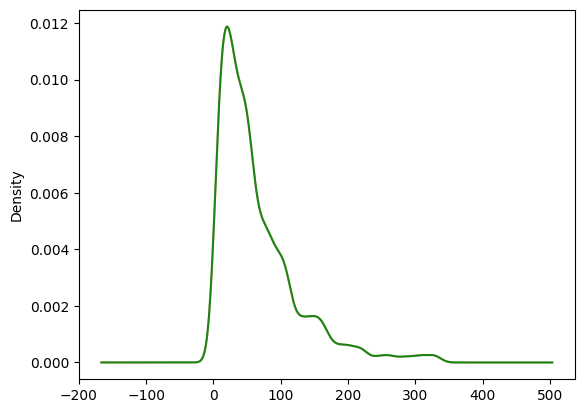

In [48]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['training_hours'].plot.density( color='red', alpha=0.3)

# new data
new_df['training_hours'].plot.density(color='green', alpha=0.9)

<Axes: >

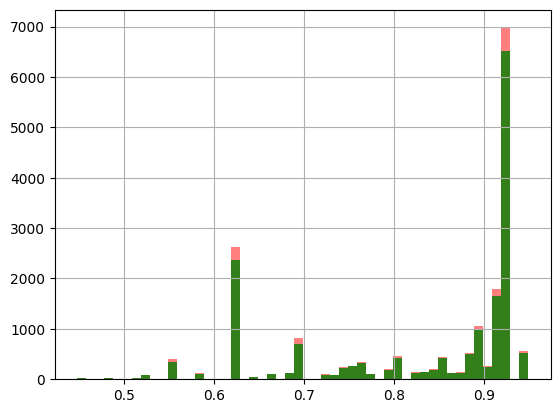

In [38]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['city_development_index'].hist(bins=50, ax=ax, color='red', alpha=0.5)

# new data
new_df['city_development_index'].hist(bins=50, ax=ax, color='green', alpha=0.8)

<Axes: ylabel='Density'>

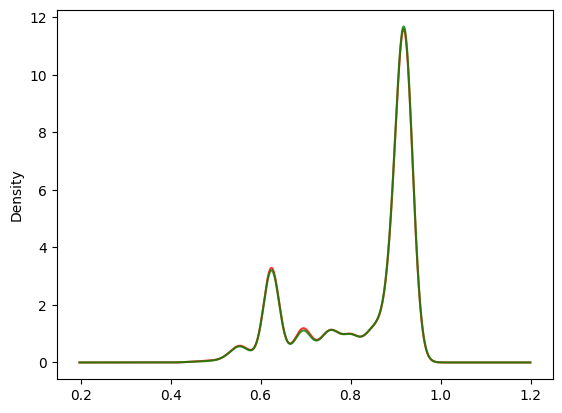

In [40]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['city_development_index'].plot.density( color='red', alpha=0.8)

# new data
new_df['city_development_index'].plot.density(color='green', alpha=0.8)

<Axes: >

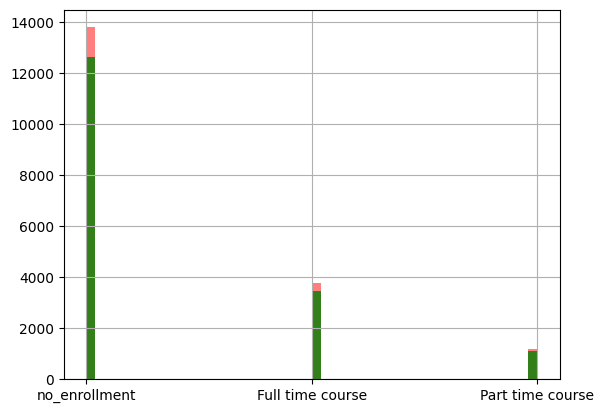

In [49]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['enrolled_university'].hist(bins=50, ax=ax, color='red', alpha=0.5)

# new data
new_df['enrolled_university'].hist(bins=50, ax=ax, color='green', alpha=0.8)

<Axes: ylabel='Density'>

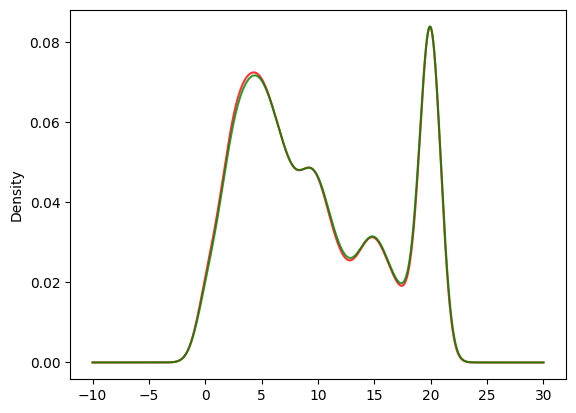

In [55]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['experience'].plot.density( color='red', alpha=0.8)

# new data
new_df['experience'].plot.density(color='green', alpha=0.8)

<Axes: >

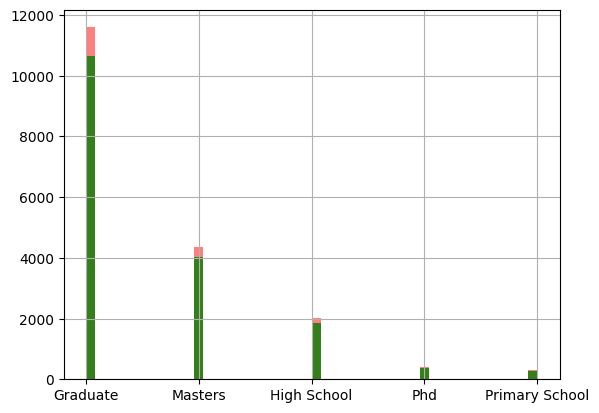

In [51]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['education_level'].hist(bins=50, ax=ax, color='red', alpha=0.5)

# new data
new_df['education_level'].hist(bins=50, ax=ax, color='green', alpha=0.8)

,df,new_df
enrolled_university,,
no_enrollment,0.721213,0.735188
Full time course,0.196106,0.200733
Part time course,0.062533,0.064079


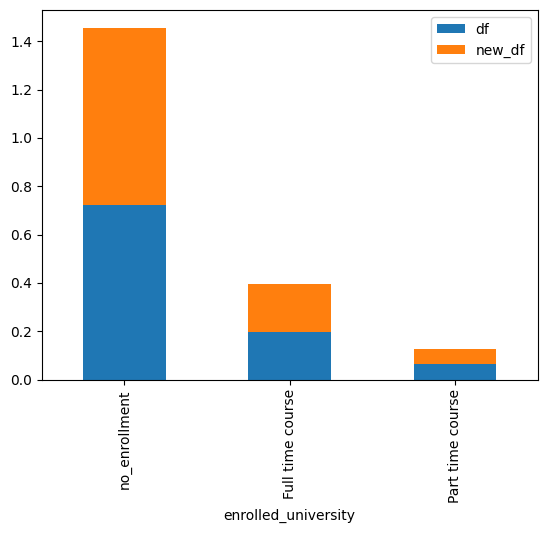

In [57]:
temp = pd.concat([
    df['enrolled_university'].value_counts()/len(df),
    new_df['enrolled_university'].value_counts()/len(new_df)
], axis = 1)
temp.columns = ['df', 'new_df']
temp.plot(kind = 'bar', stacked = True)
temp

# The Graph will show the ratio between the df and new_df, the difference should not DEFLECT MORE

### BEFORE USING CCA CHECK 200 TIMES WHEATHER IT IS MCAR OR NOT